
# Global CO₂ emissions → a source‑to‑continent reel
### A hands‑on project with **gradient‑sankey** — built *com todo cuidado e carinho* 💙

Welcome! 👋 This lesson is a **sibling of the energy‑transition tutorial**. Where that one followed
*electricity generation*, this one follows the **carbon** itself: real **Our World in Data** figures
flowing from **fossil source → continent**, animated year by year from **1950 → the latest complete
year**. Ribbon width is **million tonnes of CO₂ (MtCO₂)**, so you literally watch **Asia's coal
explode** off the chart while **Europe and North America plateau and decline**.

> If you've done `tutorial_energy.ipynb`, this will feel like home: the same **wide‑CSV → tidy‑long
> `melt`** move, the same **fixed, meaning‑carrying colours**, the same dark/neon look. The data and
> the story are new — and the story is a big one.

---

### What we'll build

A **stacked ranking race** with two columns: on the **left**, the **fossil/process sources**
(Coal, Oil, Gas, Cement, Flaring); on the **right**, the **continents** that emit them (Asia, Europe,
North America, …). Ribbons flow source → continent, their width is **MtCO₂**, and **every frame is one
year**. A footer chart tracks **total world fossil CO₂**, and a live **MtCO₂ axis** scales itself to
the source column.

### Learning outcomes

1. Load the **free OWID CO₂ dataset** (one CSV, no key) and find the right **grain** (continent
   aggregate rows vs. real countries vs. `World`).
2. **Reshape** a wide table (`coal_co2`, `oil_co2`, …) into the tidy long form
   `[year, source, continent, value]` with a single `pandas.melt`.
3. Give each source a **fixed, meaningful colour** (coal = gray, oil = brown, gas = orange,
   cement = slate, flaring = red) and drive a **fixed‑colour** source → continent flow.
4. Use the **dynamic MtCO₂ value axis** (`yaxis_node` + `yaxis_suffix=" Mt"` + `value_prefix=""`),
   `layer0_label_side`, and the **total‑emissions overlay** with `overlay_band`.
5. Read the **story** in the picture: coal's centre of gravity sliding to Asia, Europe's decline.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and `pandas`. Every step — the OWID download, the wide→long `melt`, the source→continent flow
> table — is **inlined below as a teaching step**, so you can read the whole ETL pipeline end to end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We
import it the same way the daily scripts do — by adding the repo root to `sys.path` — so we always
get the **local** copy with the newest features.

```bash
pip install gradient-sankey        # the public package
# this notebook uses the LOCAL repo copy via sys.path (see below)
```

> ⚠️ **Heads‑up — local‑only features (shipping in the next release, v1.3.0).** This reel leans on a
> few capabilities that already exist in the **local** `gradient_sankey.py` but are **not yet on the
> published pip package**:
> - the **layer‑total value axis** (`yaxis_node`) with **`yaxis_suffix=" Mt"`** and
>   **`value_prefix=""`** — an emissions axis, not dollars,
> - **`yaxis_gap`** and **`layer0_label_side`** to place the axis and the node labels,
> - the **`overlay_band`** control (push the footer line chart lower, clear of the Sankey),
> - the overlay styling kwargs (`overlay_value_suffix`, `overlay_badge`, `overlay_x_labels`).
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We only need `pandas` for the data (plus the standard library to fetch the CSV), and the library for
the visuals. Rendering an **MP4** also needs **FFmpeg** on your PATH — but the still frames
(`save_frame`) need nothing extra, so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, pathlib, urllib.request

# --- import the LOCAL gradient_sankey (repo root), exactly like the daily scripts do ---
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import pandas as pd
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the one OWID download, so a re-run is instant
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · A 2‑minute OWID primer — and the *grain* trap

**[Our World in Data](https://ourworldindata.org/co2-emissions)** maintains a superb, openly licensed
CO₂ dataset (built on the Global Carbon Project). It's a single CSV — no API key, no pagination, no
auth:

```
https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv
# mirror: https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv
```

Each row is a `(country, year)` pair with **~79 columns**. We want the **per‑source fossil/process
CO₂ in MtCO₂**:

| Column | Source label we'll show | Colour |
|---|---|---|
| `coal_co2` | Coal | dark gray |
| `oil_co2` | Oil | brown |
| `gas_co2` | Gas | orange |
| `cement_co2` | Cement | slate |
| `flaring_co2` | Flaring | red |

> There's also an `other_industry_co2` column, but it's **only half‑reported** across continents
> (missing for most of them in early years), so we deliberately **leave it out** — five clean,
> fully‑reported sources beat six flickering ones. (Confirming coverage like this before you trust a
> column is half the job of real data work.)

> 📏 **What these numbers are — and aren't.** These are **territorial / production‑based** emissions:
> *absolute* MtCO₂ released **where** the fuel is burned. They are **not** consumption‑based (which
> would re‑attribute the carbon embodied in imports to the importer), and **not** per‑capita (which
> would divide by population). So a big ribbon means "a lot of CO₂ comes out here," not "this place
> pollutes the most per person." Keep that honest distinction in mind — the per‑capita "try it
> yourself" exercise at the end tells a very different, more equitable story.

> ### ⚠️ The grain trap
> The `country` column is **not** only countries! It also holds **aggregate rows**: `World`,
> continents (`Asia`, `Europe`, `North America`, `South America`, `Africa`, `Oceania`), income groups,
> `International transport`, and more. If you naively `groupby` everything you'll **double‑count** — a
> Chinese power plant would be counted in *China*, in *Asia*, **and** in *World*. We sidestep this by
> using **exactly one grain**: the **continent aggregate rows**. Their per‑source MtCO₂ sum to ~the
> `World` row (the small gap is international aviation & shipping, which belong to no continent), so
> the right‑hand column is a tidy handful of nodes and the totals stay honest.



## 3 · Load the CSV (cached) and explore

One download, cached to disk so a re‑run is instant. Then we peek at the grain so the next step is
concrete.


In [2]:
# the OWID CO2 dataset is published on GitHub as one clean CSV (free, no API key)
OWID_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

def load_owid():
    """Download (disk-cached) the OWID CO2 CSV from its public GitHub raw URL."""
    cf = CACHE / "owid-co2-data.csv"
    if not cf.exists():
        print("downloading OWID CO2 CSV (~25 MB) ...")
        urllib.request.urlretrieve(OWID_URL, cf)
    return pd.read_csv(cf)

raw = load_owid()
print("rows x cols:", raw.shape)
src_cols_all = [c for c in raw.columns
                if c.endswith("_co2") and c.split("_")[0] in
                ("coal", "oil", "gas", "cement", "flaring", "other")]
print("\nper-source CO2 columns available:")
print("  " + ", ".join(src_cols_all))


downloading OWID CO2 CSV (~25 MB) ...


rows x cols: (50411, 79)

per-source CO2 columns available:
  cement_co2, coal_co2, flaring_co2, gas_co2, oil_co2, other_industry_co2



Let's prove the **grain trap** is real — and confirm our six continents are present for every year we
care about. Notice how `World` is roughly the **sum** of the continents (plus the international
transport that belongs to nobody), which is exactly why mixing grains would double‑count.


In [3]:
SRC_COLS = ["coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2"]
CONTINENTS = ["Asia", "North America", "Europe", "South America", "Africa", "Oceania"]

# the grain trap, made concrete: World ~= sum of the continents (so don't mix them)
for y in (1950, 1990, 2023):
    world = raw[(raw.country == "World") & (raw.year == y)][SRC_COLS].sum().sum()
    conts = raw[(raw.country.isin(CONTINENTS)) & (raw.year == y)][SRC_COLS].sum().sum()
    print(f"  {y}: World = {world:,.0f} Mt   vs   sum(continents) = {conts:,.0f} Mt"
          f"   (gap = {world - conts:,.0f}, intl. transport)")

# every continent reports every year in our window?
present = (raw[raw.country.isin(CONTINENTS)]
          .query("1950 <= year <= 2023")
          .groupby("year")["country"].nunique())
print("\ncontinents present per year (want 6):", present.min(), "->", present.max())


  1950: World = 5,925 Mt   vs   sum(continents) = 5,795 Mt   (gap = 131, intl. transport)
  1990: World = 22,396 Mt   vs   sum(continents) = 21,848 Mt   (gap = 548, intl. transport)


  2023: World = 37,669 Mt   vs   sum(continents) = 36,586 Mt   (gap = 1,083, intl. transport)

continents present per year (want 6): 6 -> 6



## 4 · Reshape wide → tidy long (the heart of this lesson) 🔑

The library wants a **tidy long** frame: one row per flow, columns
`[year, source, continent, value]`. Our CSV is **wide**: each source is its *own column*. The bridge
between them is a single **`pandas.melt`** — the move you'll use again and again.

We:
1. keep only the **continent** rows and our **year window**,
2. fill source gaps with `0.0` (a continent with no flaring that year is a real zero, not missing),
3. `melt` the five source columns into two columns: a `src_col` name and its `value`,
4. map `coal_co2 → "Coal"` etc., rename `country → continent`, and
5. group to one clean row per `(year, source, continent)`.

Rather than freeze the end year, we **auto-detect the latest complete year** — the most recent year
for which **every** continent reports — so the reel always runs `1950 → latest complete`, never
trailing off into a half-empty final frame.


In [4]:
Y0 = 1950

# auto-detect the latest COMPLETE year (every continent reporting),
# so we never freeze the end year or trail off into a half-empty final frame.
cont_rows = raw[raw.country.isin(CONTINENTS)]
full = (cont_rows.dropna(subset=SRC_COLS, how="all")
        .groupby("year")["country"].nunique())
Y1 = int(full[full >= len(CONTINENTS)].index.max())
print(f"latest complete year (all {len(CONTINENTS)} continents reporting): {Y1}")

sub = raw[raw.country.isin(CONTINENTS) & raw.year.between(Y0, Y1)].copy()
sub[SRC_COLS] = sub[SRC_COLS].fillna(0.0)

# the one move that matters: wide source columns -> tidy long rows
long = sub.melt(id_vars=["country", "year"], value_vars=SRC_COLS,
                var_name="src_col", value_name="value")

# pretty source labels + tidy column names
SRC_LABEL = {
    "coal_co2": "Coal", "oil_co2": "Oil", "gas_co2": "Gas",
    "cement_co2": "Cement", "flaring_co2": "Flaring",
}
long["source"] = long["src_col"].map(SRC_LABEL)
long = long.rename(columns={"country": "continent"})[["year", "source", "continent", "value"]]
long = long.groupby(["year", "source", "continent"], as_index=False)["value"].sum()
# Drop genuine-zero flows here *only* because a zero-width ribbon draws nothing — not because the
# data is missing. We treated the gaps above as real zeros (fillna(0.0)); we simply skip plotting them.
long = long[long["value"] > 0]                       # drop zero-width (undrawable) flows

print(f"{len(long)} tidy [year, source, continent, value] rows, {long.year.min()}-{long.year.max()}")
long.head(8)


latest complete year (all 6 continents reporting): 2024


2188 tidy [year, source, continent, value] rows, 1950-2024


,year,source,continent,value
0,1950,Cement,Africa,2.014
1,1950,Cement,Asia,6.326
2,1950,Cement,Europe,32.755
3,1950,Cement,North America,22.440
4,1950,Cement,Oceania,0.760
5,1950,Cement,South America,2.606
6,1950,Coal,Africa,68.866
7,1950,Coal,Asia,305.086



### A first read of the story

Before we draw anything, let's confirm the **story** is in the numbers. Watch **coal in Asia** climb
from a footnote to the single biggest flow on the planet, while **Europe's total** quietly falls — the
whole reel in two print statements.


In [5]:
asia = long[long.continent == "Asia"]
print("Asia — coal vs oil+gas, MtCO2:")
for y in (1950, 1980, 2000, 2010, 2023):
    coal = asia[(asia.year == y) & (asia.source == "Coal")]["value"].sum()
    og   = asia[(asia.year == y) & (asia.source.isin(["Oil", "Gas"]))]["value"].sum()
    print(f"  {y}: coal {coal:7.0f}   oil+gas {og:7.0f}")

# Europe is going the other way
eu = long[long.continent == "Europe"]
print("\nEurope total fossil CO2, MtCO2:")
for y in (1980, 2000, 2010, 2023):
    print(f"  {y}: {eu[eu.year == y]['value'].sum():7.0f}")


Asia — coal vs oil+gas, MtCO2:
  1950: coal     305   oil+gas      89
  1980: coal    1939   oil+gas    2114
  2000: coal    4275   oil+gas    4381
  2010: coal    9260   oil+gas    6059
  2023: coal   13058   oil+gas    8380

Europe total fossil CO2, MtCO2:
  1980:    7754
  2000:    6089
  2010:    6054
  2023:    4831



## 5 · Layers and fixed colours

Two layers: **sources on the left**, **continents on the right**. The colours **carry meaning**, so we
give each source a fixed tone: **coal = dark gray, oil = brown, gas = orange, cement = slate, flaring =
red**. The continents get their own accent colours.

We order the right column by each continent's **all‑time total**, so the biggest (Asia) leads.


In [6]:
# fixed, meaning-carrying colour per source (coal=gray, oil=brown, gas=orange, ...)
SRC_COLOR = {
    "Coal": "#5A5F66", "Oil": "#8B5A2B", "Gas": "#F5871F",
    "Cement": "#7B8794", "Flaring": "#E5484D",
}
CONT_COLOR = {
    "Asia": "#FF5D73", "North America": "#4EA8DE", "Europe": "#9B5DE5",
    "South America": "#00BBF9", "Africa": "#F4A261", "Oceania": "#80ED99",
}

# left layer in our declared (visual) source order; right layer by all-time total
sources = [s for s in SRC_COLOR if s in set(long.source)]
continents = (long.groupby("continent")["value"].sum()
              .reindex(CONTINENTS).dropna()
              .sort_values(ascending=False).index.tolist())
LAYERS = [sources, continents]

node_colors = {**{s: SRC_COLOR[s] for s in sources},
               **{c: CONT_COLOR[c] for c in continents}}

print("sources    (left) :", sources)
print("continents (right):", continents)


sources    (left) : ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring']
continents (right): ['Asia', 'Europe', 'North America', 'Africa', 'South America', 'Oceania']



## 6 · The total‑emissions overlay

The footer chart is a bar‑chart‑race style line of **total world fossil CO₂**, one point per year — the
global total growing under the shifting mix. We also build the **year tick labels**.


In [7]:
years = sorted(long["year"].unique())
total = [float(long[long.year == y]["value"].sum()) for y in years]   # world MtCO2 each year
xlabels = [str(y) for y in years]
print(f"world fossil CO2: {total[0]:,.0f} Mt ({years[0]}) -> {total[-1]:,.0f} Mt ({years[-1]})")


world fossil CO2: 5,795 Mt (1950) -> 36,982 Mt (2024)


## 7 · Building the visual — every knob explained

We hand the tidy `long` + `LAYERS` to `from_dataframe`, then drive the render with the reel's design.
Here's what each knob does in **this** reel:

| Knob | Value | Why |
|---|---|---|
| `ranking_mode` | `True` | reorder sources/continents by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with MtCO₂ (biggest = tallest) |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.55` | soft neon glow behind the ribbons |
| `n_segments` | `100` | smooth gradients along each ribbon |
| `yaxis_node` | `sources[0]` ⚠️ | draw a value axis scaled to the **source‑layer total** |
| `yaxis_suffix` / `value_prefix` | `" Mt"` / `""` ⚠️ | ticks read like `15000 Mt` — **emissions, not dollars** |
| `yaxis_gap` / `layer0_label_side` | `0.15` / `"right"` ⚠️ | axis hugs the source column; names on the right |
| `overlay_series` / `overlay_x_labels` | total / years | the footer race chart |
| `overlay_band` | `(0.18, 0.56)` ⚠️ | push the line chart **lower**, clear of the Sankey |

> 💡 **Fixed colours, on purpose.** We *don't* pass `dynamic_color_mode` here, so every source keeps
> its colour all the way through. (The production script exposes a `--cmap` switch if you ever want
> rank colouring instead — try it as an exercise.)

First, build the renderer — the single call that ingests everything.


In [8]:
sk = Sankey.from_dataframe(
    df=long, layers=LAYERS,
    time_col="year", source_col="source", target_col="continent", value_col="value",
    node_colors=node_colors,
)
anchor = sources[0]    # any source identifies the left layer for the MtCO2 axis
print(f"{len(sk.frames)} frames (years):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("MtCO2 axis anchored on the source layer of:", anchor)


75 frames (years): 1950 -> 2024
MtCO2 axis anchored on the source layer of: Coal



## 8 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render three years that
bookend the story:

- **1950** — Coal & Oil out of Europe and North America; Asia is a sliver,
- **1990** — the centre of gravity already shifting east,
- **2023** — Asia's coal towers over everything, Europe visibly smaller.

The fixed colours, the **MtCO₂ axis** (`yaxis_node` + `value_prefix=""`) and `layer0_label_side` all
work in stills.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_1950.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_1950.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_1990.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_1990.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_2023.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_2023.png


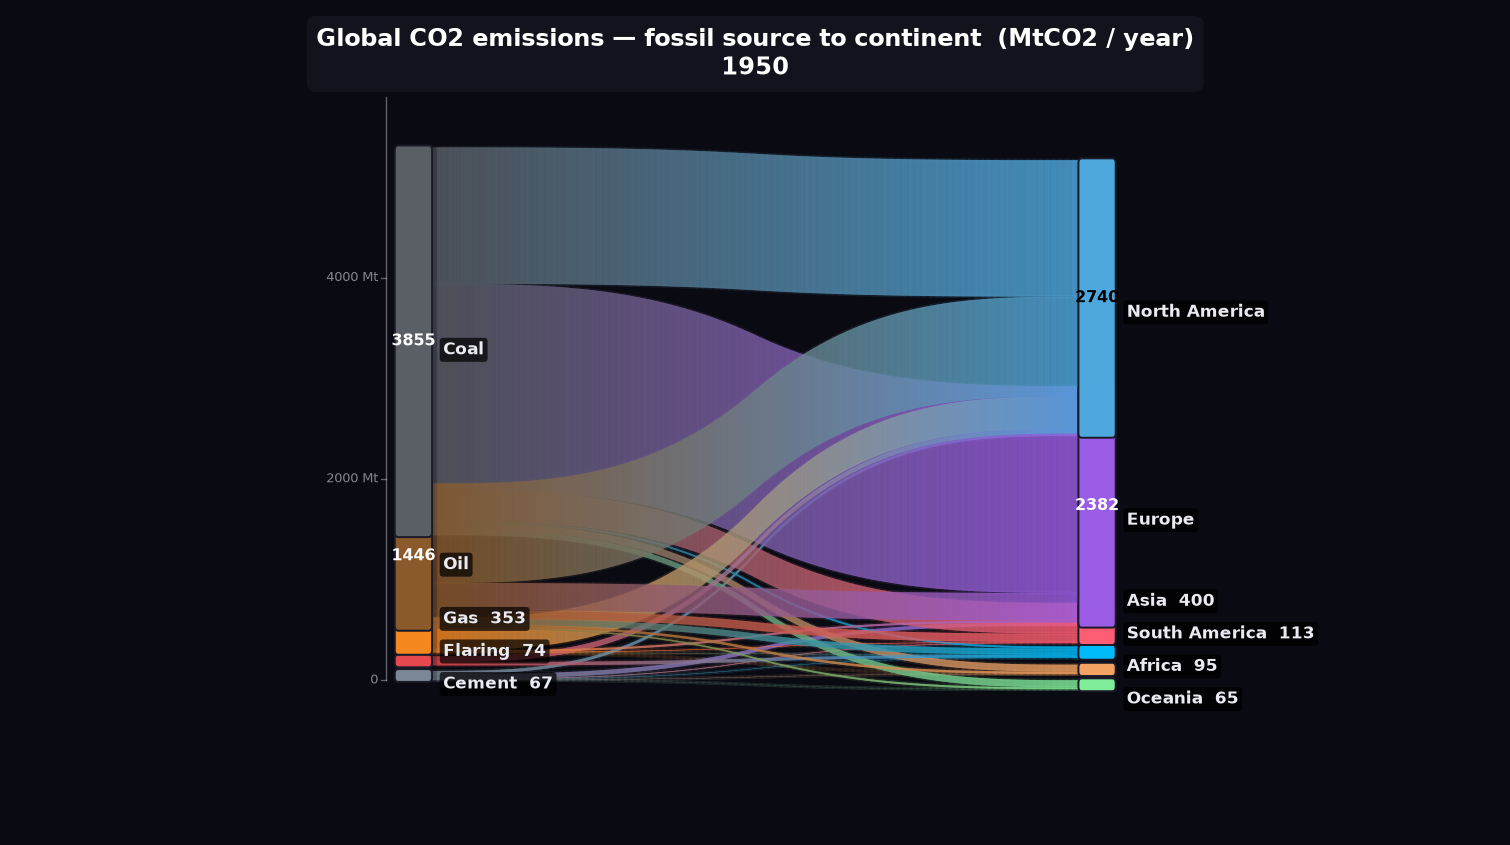

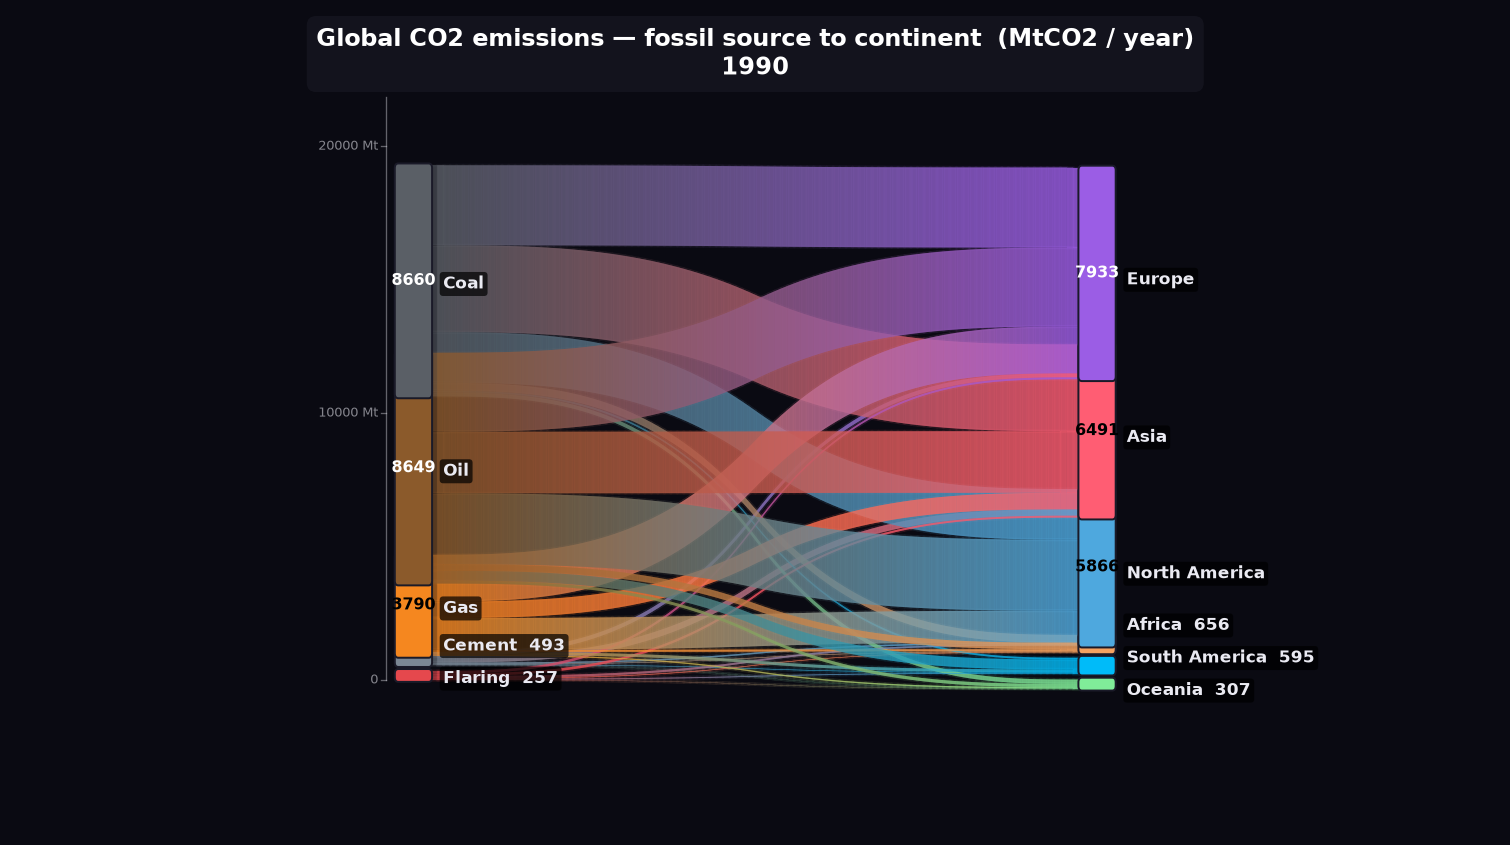

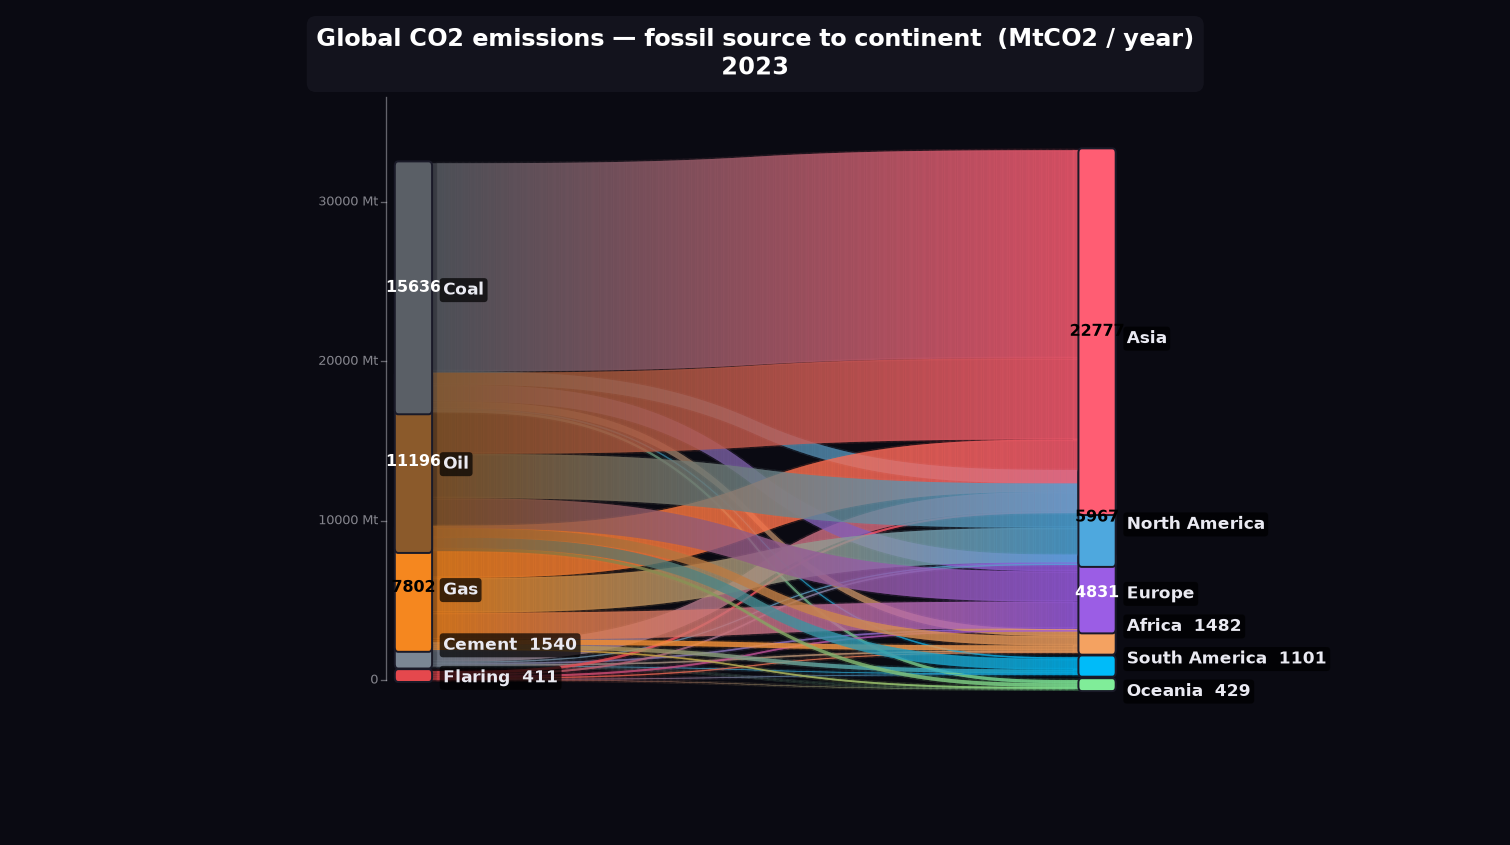

In [9]:
still_design = dict(
    figsize=(16, 9), dpi=95, font_size=13, title_fontsize=18, padding=2.8,
    margin_top=0.16, margin_bottom=0.20,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
    yaxis_node=anchor, yaxis_suffix=" Mt",           # MtCO2 axis, scaled to the source-layer TOTAL
    yaxis_gap=0.15, layer0_label_side="right",       # axis hugs the sources; names on the right
    value_prefix="",                                 # emissions, not dollars
)

year_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for yr in ("1950", "1990", "2023"):
    if yr not in year_to_index:
        continue
    p = os.path.join(ASSETS, f"co2_{yr}.png")
    sk.save_frame(p, frame_index=year_to_index[yr],
                  title="Global CO2 emissions — fossil source to continent  (MtCO2 / year)",
                  **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation 🎬

A tiny clip to prove the motion, with the **full** reel design: dark theme, glow, the MtCO₂ axis, and
the total‑emissions overlay. We keep it short for speed (a few seconds). The cell **skips gracefully**
if FFmpeg isn't installed — but if it is, you'll see Asia's coal ribbon swell in real time.


In [10]:
sample_mp4 = os.path.join(ASSETS, "co2_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=8, quality="medium", n_workers=2,
        title="Global CO2 emissions — fossil source to continent  (MtCO2 / year)",
        font_size=13, title_fontsize=20, padding=2.8,
        margin_top=0.16, margin_bottom=0.20,
        ranking_mode=True, stacked_mode=True,
        theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
        yaxis_node=anchor, yaxis_suffix=" Mt", yaxis_gap=0.15, layer0_label_side="right",
        value_prefix="",                                              # emissions, not dollars
        overlay_series=total, overlay_x_labels=xlabels,
        overlay_label="Total world fossil CO2  (MtCO2 / year)",
        overlay_color="#FF7A59", overlay_value_suffix=" Mt", overlay_badge="WORLD",
        overlay_band=(0.18, 0.56),                                    # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 2
  - Nodes per layer: [5, 6]
  - FPS: 24, Duration: 8s
  - Quality: medium
  - Total frames: 192
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Static

Pre-computing 192 frames...
  Pre-computation: 0.01s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 678.94s (0.3 fps)

Concatenating 2 chunks...


  Concatenation: 0.82s

Animation saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_sample.mp4
Total time: 679.83s (0.3 effective fps)
rendered: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\co2_sample.mp4



### The full reel — one function

Everything above can be wrapped into one function. The two reusable pieces are the **flow builder**
(`co2_flows`, our §3–§4 melt + auto‑complete‑year logic) and the **render call** (§7–§8). To make a
full ~40 s clip, just call `sk.animate(...)` with a longer `duration_seconds` and `quality="high"`,
or pass `dynamic_color_mode="ranking", dynamic_colormap="inferno"` (and drop the fixed `node_colors`)
to recolour by live rank instead of the fixed source colours.

> 🗂️ A nice habit for your own renders: stamp every output filename with a **big‑endian, sortable**
> date‑time prefix (`%Y-%m-%d-%Hh%M`, with `:` → `h` because it's illegal in paths) — so your files
> always sort chronologically.



## 9 · Recap & try it yourself

🎉 **You built the whole reel** — from a raw 79‑column CSV to an animated gradient Sankey that shows
the global emissions story, source by source, continent by continent. Remember the framing: these are
**territorial / production‑based absolute** emissions (where the CO₂ is released) — not
consumption‑based, not per‑capita.

**The pipeline, in one breath:** download the OWID CO₂ CSV (cached) → pick the **continent grain**
(avoid the double‑counting trap) → **`melt`** the wide source columns into tidy `[year, source,
continent, value]` → fixed **source colours** → **total‑emissions** overlay → `from_dataframe` →
`save_frame` stills + `animate` with the dark theme, the **MtCO₂ axis** (`value_prefix=""`,
`yaxis_suffix=" Mt"`) and `overlay_band`.

### 🧪 Try it yourself

1. **Rank colours.** Pass `dynamic_color_mode="ranking", dynamic_colormap="inferno"` to `animate`
   (and drop the fixed `node_colors`) to recolour by live rank.
2. **Flip the flow.** Make it **continent → source** by swapping `source_col`/`target_col` and the
   layer order — now the left column is continents and you read *what each continent burns*.
3. **One country.** Replace the `CONTINENTS` filter with a single country (e.g. `["China"]` or
   `["United States"]`) to tell that nation's emissions story — same `melt`, same knobs.
4. **Per‑capita.** OWID also has `*_co2_per_capita` columns. Swap the value columns for a very
   different — and more equitable — picture.
5. **A different window.** Set `Y0 = 1850` to include the whole Industrial era (coal's long reign),
   or `Y0 = 2000` to zoom into the China‑coal decades.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- Our World in Data — CO₂: https://ourworldindata.org/co2-emissions  (CSV is free, no API key)
- The OWID CO₂ CSV (GitHub raw): https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv
- Companion tutorials: `notebooks/03_tutorial_energy.ipynb`, `notebooks/06_tutorial_refugees.ipynb`,
  `notebooks/02_tutorial_stablecoins.ipynb`, `notebooks/01_tutorial_nvidia_income.ipynb`

> 💡 Remember: the **MtCO₂ value axis** (`yaxis_node` + `value_prefix=""` + `yaxis_suffix=" Mt"`),
> `yaxis_gap`, `layer0_label_side` and `overlay_band` are **local‑only** today — they ship in
> **v1.3.0**. Until then, import the local module via `sys.path` (as we did in §1) and everything
> just works. 💙

*Built com todo cuidado e carinho. Data: Our World in Data — CO₂ (free, no API key). Happy hacking!*
